In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale
from sklearn.svm import SVC 
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.decomposition import PCA

Loding the data

In [3]:
df = pd.read_csv("../data/UCI_Credit_Card.csv")

df.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


Renaming the last col to shorter name

In [4]:
df.rename({'default.payment.next.month':'DEFAULT'}, axis='columns', inplace=True)

Droping the ID column

In [5]:
df.drop('ID', axis=1, inplace=True)
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


checking data types

In [6]:
df.dtypes

LIMIT_BAL    float64
SEX            int64
EDUCATION      int64
MARRIAGE       int64
AGE            int64
PAY_0          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
DEFAULT        int64
dtype: object

In [7]:
df['SEX'].unique()

array([2, 1])

In [8]:
df['EDUCATION'].unique()  

array([2, 1, 3, 5, 4, 6, 0])

In [9]:
df['MARRIAGE'].unique()  

array([1, 2, 3, 0])

In [10]:
len(df.loc[(df['EDUCATION'] == 0)|(df['MARRIAGE'] == 0)])

68

In [11]:
len(df)

30000

Deleting the 68 rows with 0 values in ECUCATION and MARRIAGE

In [12]:
df_no_missing = df.loc[(df['EDUCATION'] != 0) & (df['MARRIAGE'] != 0)]

In [13]:
len(df_no_missing)

29932

In [14]:
df_no_missing['EDUCATION'].unique()  

array([2, 1, 3, 5, 4, 6])

In [15]:
df_no_missing['MARRIAGE'].unique() 

array([1, 2, 3])

Downsample the data first we split it into default and non default

In [16]:
df_no_default = df_no_missing[df_no_missing['DEFAULT'] == 0]
df_default = df_no_missing[df_no_missing['DEFAULT'] == 1]


Now we downsample the dataset

In [17]:
df_no_default_downsample = resample(df_no_default, replace=False, n_samples=1000, random_state=42)
len(df_no_default_downsample)

1000

In [18]:
df_default_downsample = resample(df_default, replace=False, n_samples=1000, random_state=42)
len(df_no_default_downsample)

1000

Now lets merge the two dataset

In [19]:
df_downsample = pd.concat([df_default_downsample, df_no_default_downsample])
len(df_downsample)

2000

In [20]:
X = df_downsample.drop('DEFAULT', axis=1).copy()
X.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
19982,300000.0,2,1,1,47,3,2,2,2,2,...,5000.0,5000.0,5000.0,5000.0,0.0,0.0,0.0,0.0,0.0,0.0
19350,80000.0,2,2,2,36,2,0,0,-2,-2,...,0.0,0.0,0.0,0.0,1700.0,0.0,0.0,0.0,0.0,0.0
17057,30000.0,2,3,2,22,2,2,0,0,0,...,29047.0,29507.0,11609.0,11711.0,0.0,1687.0,1147.0,524.0,400.0,666.0
26996,80000.0,1,1,2,34,2,2,2,2,2,...,63827.0,64682.0,65614.0,67007.0,2800.0,3000.0,2500.0,2600.0,2600.0,2600.0
23621,210000.0,2,3,1,44,-2,-2,-2,-2,-2,...,17706.0,0.0,5646.0,14793.0,13462.0,17706.0,0.0,5646.0,14793.0,7376.0


In [21]:
y = df_downsample['DEFAULT'].copy()
y.head()

19982    1
19350    1
17057    1
26996    1
23621    1
Name: DEFAULT, dtype: int64

In [22]:
pd.get_dummies(X, columns=['MARRIAGE']).head()

,LIMIT_BAL,SEX,EDUCATION,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,...,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3
19982,300000.0,2,1,47,3,2,2,2,2,2,...,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,False
19350,80000.0,2,2,36,2,0,0,-2,-2,-2,...,0.0,1700.0,0.0,0.0,0.0,0.0,0.0,False,True,False
17057,30000.0,2,3,22,2,2,0,0,0,0,...,11711.0,0.0,1687.0,1147.0,524.0,400.0,666.0,False,True,False
26996,80000.0,1,1,34,2,2,2,2,2,2,...,67007.0,2800.0,3000.0,2500.0,2600.0,2600.0,2600.0,False,True,False
23621,210000.0,2,3,44,-2,-2,-2,-2,-2,-2,...,14793.0,13462.0,17706.0,0.0,5646.0,14793.0,7376.0,True,False,False


In [23]:
X_encoded = pd.get_dummies(X, columns=['SEX', 'EDUCATION','MARRIAGE', 'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6'])
X_encoded.head()

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,...,PAY_5_7,PAY_6_-2,PAY_6_-1,PAY_6_0,PAY_6_2,PAY_6_3,PAY_6_4,PAY_6_5,PAY_6_6,PAY_6_7
19982,300000.0,47,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,0.0,0.0,...,False,False,False,False,True,False,False,False,False,False
19350,80000.0,36,19671.0,20650.0,0.0,0.0,0.0,0.0,1700.0,0.0,...,False,True,False,False,False,False,False,False,False,False
17057,30000.0,22,29793.0,29008.0,29047.0,29507.0,11609.0,11711.0,0.0,1687.0,...,False,False,False,True,False,False,False,False,False,False
26996,80000.0,34,61231.0,62423.0,63827.0,64682.0,65614.0,67007.0,2800.0,3000.0,...,False,False,False,False,True,False,False,False,False,False
23621,210000.0,44,11771.0,13462.0,17706.0,0.0,5646.0,14793.0,13462.0,17706.0,...,False,True,False,False,False,False,False,False,False,False


Split the data into train and test

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y , random_state=42)
X_train_scaled = scale(X_train)
X_test_scaled = scale(X_test)

Making the SVM

In [25]:
clf_svm = SVC(random_state=42)
clf_svm.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Now lets see the performance of the SVM 

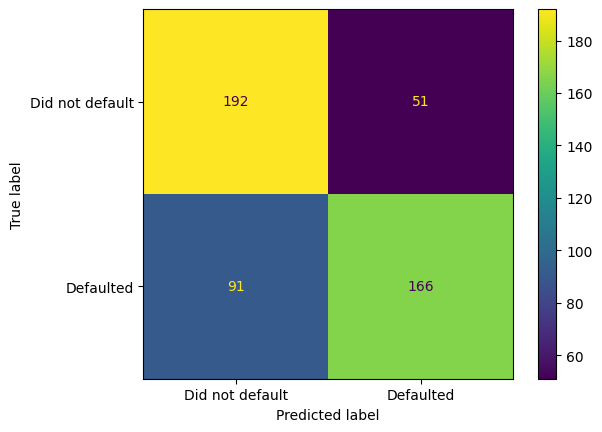

In [26]:
ConfusionMatrixDisplay.from_estimator(clf_svm, X_test_scaled, y_test, display_labels=["Did not default", "Defaulted"])

Lets try to optimize it using GridSearchCV()

In [33]:
param_grid = [{'C':[0.5, 1, 10, 100],'gamma': ['scale', 1, 0.1 , 0.01, 0.001, 0.0001], 'kernel':['rbf']}]

optimal_params = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', verbose=0 )

In [28]:
optimal_params.fit(X_train_scaled,y_train)
print(optimal_params.best_params_)

{'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}


In [29]:
clf_svm = SVC(random_state=42, C=100, gamma=0.001)
clf_svm.fit(X_train_scaled,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.001
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


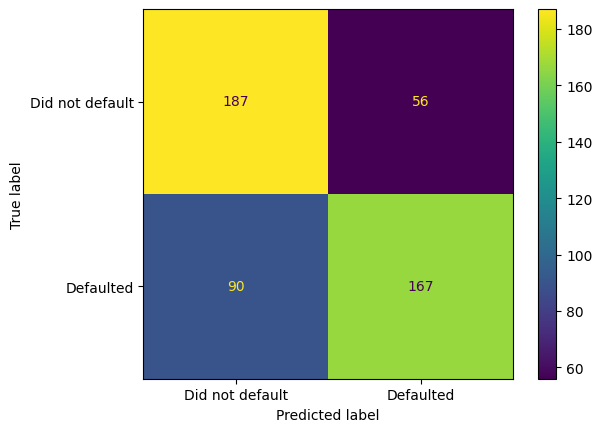

In [30]:
ConfusionMatrixDisplay.from_estimator(clf_svm, X_test_scaled, y_test, display_labels=["Did not default", "Defaulted"])

In [31]:
len(df_downsample.columns)

24

Lets implement PCA for visualization

<function matplotlib.pyplot.show(close=None, block=None)>

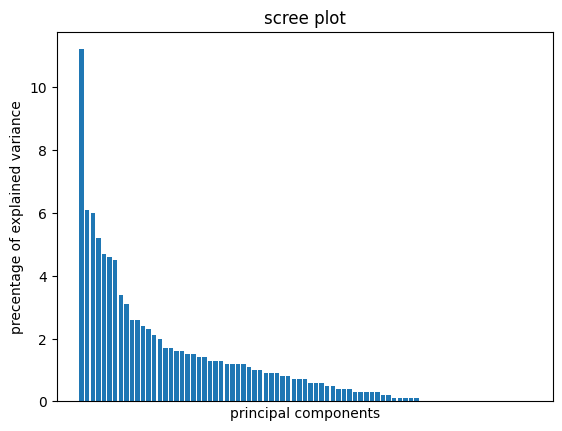

In [32]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

per_var = np.round(pca.explained_variance_ratio_*100, decimals=1)
labels = [str(x) for x in range(1,len(per_var)+1)]

plt.bar(x=range(1,len(per_var)+1), height=per_var)
plt.tick_params(axis='x', which='both',bottom=False, top=False, labelbottom=False)
plt.ylabel('precentage of explained variance')
plt.xlabel('principal components')
plt.title('scree plot')
plt.show